In [1]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    theta = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
    
    class RadarTransform(PolarAxes.PolarTransform):
        def transform_path_non_affine(self, path):
            if path._interpolation_steps > 1:
                path = path.interpolated(num_vars)
            return Path(self.transform(path.vertices), path.codes)

    class RadarAxes(PolarAxes):
        name = 'radar'
        PolarTransform = RadarTransform

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)
 
        ##############################################################################################
        # Custom function for a plot with 7 labels.
        # If it does not looks good for your data, try this function instead:
        # def set_varlabels(self, labels):
        #     self.set_thetagrids(np.degrees(theta), labels)
        def set_varlabels(self, labels):
            angles_deg = np.degrees(theta)
            self.set_thetagrids(angles_deg, labels)

            for idx, (angle, label) in enumerate(zip(angles_deg, self.get_xticklabels())):
                label.set_fontsize(14)
                label.set_verticalalignment("center")
                label.set_horizontalalignment("center")

                if abs(angle) < 1 or abs(angle - 180) < 10 or abs(angle - 360) < 1:
                    continue

                if idx == 5:
                    offset = - 0.075 
                else:
                    offset = - 0.055

                label.set_position((label.get_position()[0], label.get_position()[1] + offset))
        ##############################################################################################

        def _gen_axes_patch(self):
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars, radius=0.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                spine = Spine(axes=self, spine_type='circle', path=Path.unit_regular_polygon(num_vars))
                spine.set_transform(Affine2D().scale(0.5).translate(0.5, 0.5) + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

def parse_mrr_file(eval_file, inference_file):
    """Extract MRR values from a YAML file."""
    mrr_values = {}

    with open(eval_file, 'r') as file:
        data = yaml.safe_load(file)
        
        mrr_values["global_mrr"] = data.get("Global_MRR", 0)
        mrr_values["made_directed_relations"] = data.get("made_directed_relations", {}).get("Global_MRR", 0)
        mrr_values["target_relations"] = data.get("target_relations", {}).get("Global_MRR", 0)
        mrr_values['target_frequent'] = data.get('target_relations_by_frequency',{}).get('indication',{}).get('Frequent_MRR', 0)
        mrr_values['target_infrequent'] = data.get('target_relations_by_frequency',{}).get('indication',{}).get('Infrequent_MRR', 0)
        
    with open(inference_file, 'r') as file:   
        data = yaml.safe_load(file)

        mrr_values['inference_mrr'] = data.get('Inference MRR', 0)

        
    return mrr_values

def parse_model_metrics(base_dirs):
    models_data = {}

    for key, dl_dir in base_dirs.items():
        dl_path = dl_dir
        models_data[key] = {}

        for run in ['run1', 'run2']:
            run_path = os.path.join(dl_path, run)
            models_data[key][run] = {}

            for dirpath, dirnames, filenames in os.walk(run_path):
                if 'evaluation_metrics.yaml' in filenames and 'inference_metrics.yaml' in filenames:
                    model_name = os.path.basename(dirpath)

                    eval_file = os.path.join(dirpath, 'evaluation_metrics.yaml')
                    inference_file = os.path.join(dirpath, 'inference_metrics.yaml')

                    mrr_values = parse_mrr_file(eval_file, inference_file)

                    models_data[key][run][model_name] = mrr_values

        # Now compute best metrics across runs  
        models_data[key]["best"] = {}
        all_models = set(models_data[key]['run1'].keys()).union(models_data[key]['run2'].keys())

        for model in all_models:
            best_metrics = {}
            for metric in ['global_mrr', 'made_directed_relations', 'target_relations', 'target_frequent', 'target_infrequent', 'inference_mrr']:
                val1 = models_data[key]['run1'].get(model, {}).get(metric, 0)
                val2 = models_data[key]['run2'].get(model, {}).get(metric, 0)
                best_metrics[metric] = max(val1, val2)
            models_data[key]["best"][model] = best_metrics

    return models_data

def plot_radar(results, 
               experiment1, 
               run,
               metric1, 
               experiment2=None, 
               metric2=None, 
               y_lim=0.7, 
               title="Radar Plot", 
               legend_labels=None, 
               colors=("red", "blue"), 
               font_size=14, 
               desired_order=["ANALOGY", "ComplEx", "HolE", "RESCAL", "DistMult", "TransE", "TransD"], 
               rgrid=None, 
               savefile=None):
    
    if experiment2 and experiment2 != experiment1 and metric2 is None:
        comparison_type = "exp"
        metric2 = metric1
    elif experiment2 is None and metric2 and metric2 != metric1:
        comparison_type = "metric"
        experiment2 = experiment1
    elif experiment2 is None and metric2 is None:
        comparison_type = "single"
        experiment2 = experiment1
        metric2 = None
    else:
        raise ValueError("Invalid combination of arguments.")

    for exp in [experiment1, experiment2]:
        if exp not in results:
            raise ValueError(f"Experiment '{exp}' not found in the results.")
        if run not in results[exp]:
            raise ValueError(f"Run '{run}' not found in experiment '{exp}'.")

    models = list(results[experiment1][run].keys())
    models = [m for m in desired_order if m in models]
    N = len(models)
    theta = radar_factory(N, frame='polygon')

    values_1 = [results[experiment1][run][m][metric1] for m in models]
    values_2 = [results[experiment2][run][m][metric2] for m in models] if comparison_type != "single" else None

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='radar'))
    ax.set_ylim(0, y_lim)

    if rgrid is None:
        rgrid = np.arange(0, y_lim, 0.1)
    ax.set_rgrids(rgrid, angle=np.degrees(theta[N-1]), ha='center', color='grey', fontsize=font_size)

    ax.set_title(title, ha='center', fontsize=font_size + 2, weight='bold', pad=15)

    if comparison_type == "exp":
        legend1 = legend_labels[0] if legend_labels else experiment1
        legend2 = legend_labels[1] if legend_labels else experiment2
    elif comparison_type == "metric":
        legend1 = legend_labels[0] if legend_labels else metric1
        legend2 = legend_labels[1] if legend_labels else metric2
    else:
        legend1 = legend_labels[0] if legend_labels else f"{experiment1} - {metric1}"
        legend2 = None

    ax.plot(theta, values_1, color=colors[0], label=legend1)
    if values_2:
        ax.plot(theta, values_2, color=colors[1], label=legend2)

    ax.set_varlabels(models)
    for label in ax.get_xticklabels():
        label.set_fontsize(font_size)

    lines, labels = ax.get_legend_handles_labels()
    if labels:
        ax.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=font_size)

    if savefile is None:
        if comparison_type == "exp":
            fname = f"radar_{experiment1}_vs_{experiment2}_{metric1}_{run}.svg"
        elif comparison_type == "metric":
            fname = f"radar_{experiment1}_{metric1}_vs_{metric2}_{run}.svg"
        else:
            fname = f"radar_{experiment1}_{metric1}_{run}.svg"
        savefile = fname.replace("/", "-")

    plt.tight_layout()
    plt.savefig(savefile, format="svg", bbox_inches='tight')


In [2]:
results = parse_model_metrics({"with_dl1": '/home/galadriel/dr_benchmark/DL1experiment/withDL1/models', 
                               "without_dl1": '/home/galadriel/dr_benchmark/DL1experiment/withoutDL1/models',
                               "without_dl1_indication": '/home/galadriel/dr_benchmark/DL1experiment/withoutDL1/models_indication',
                               "dl2": '/home/galadriel/dr_benchmark/DL2experiment/models',
                               "dl2_indication": '/home/galadriel/dr_benchmark/DL2experiment/models_indication',
                               "zero_shot": '/home/galadriel/dr_benchmark/DL3experiment/zero_shot/models'})

# Figure 1

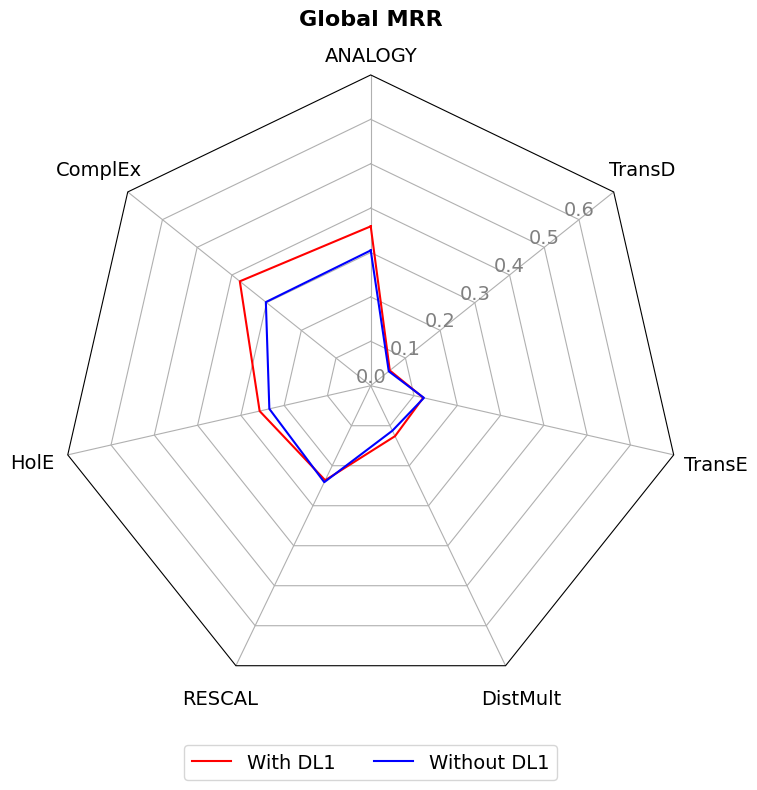

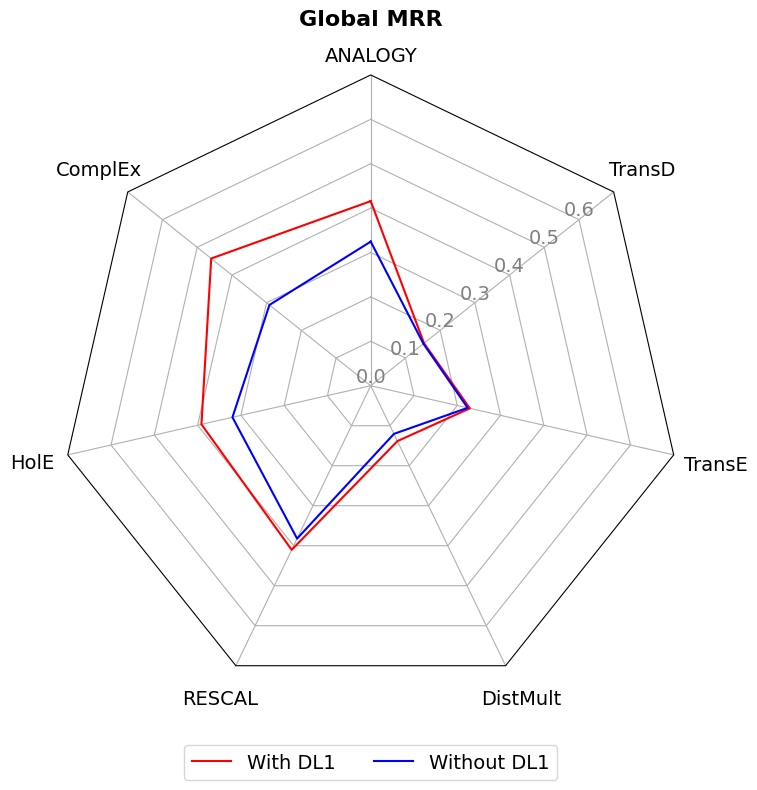

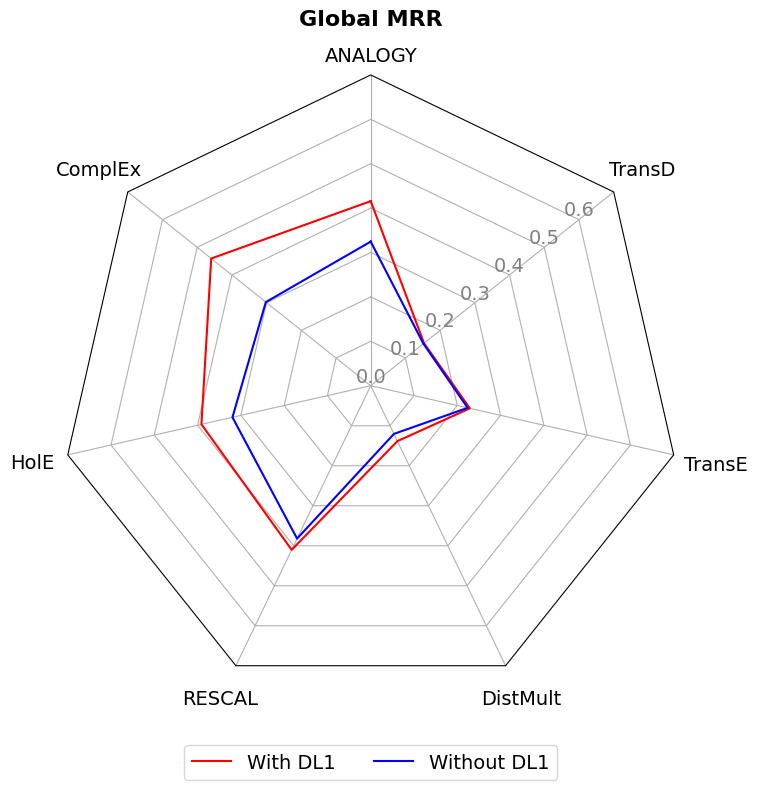

In [3]:
experiment1 = "with_dl1"  
experiment2 = "without_dl1" 
run = "run1" 
metric = "global_mrr" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"
title = "Global MRR"
y_lim=0.7
labels = ["With DL1", "Without DL1"]
colors = ("red", "blue")
font_size=14

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "run2" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "best"
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


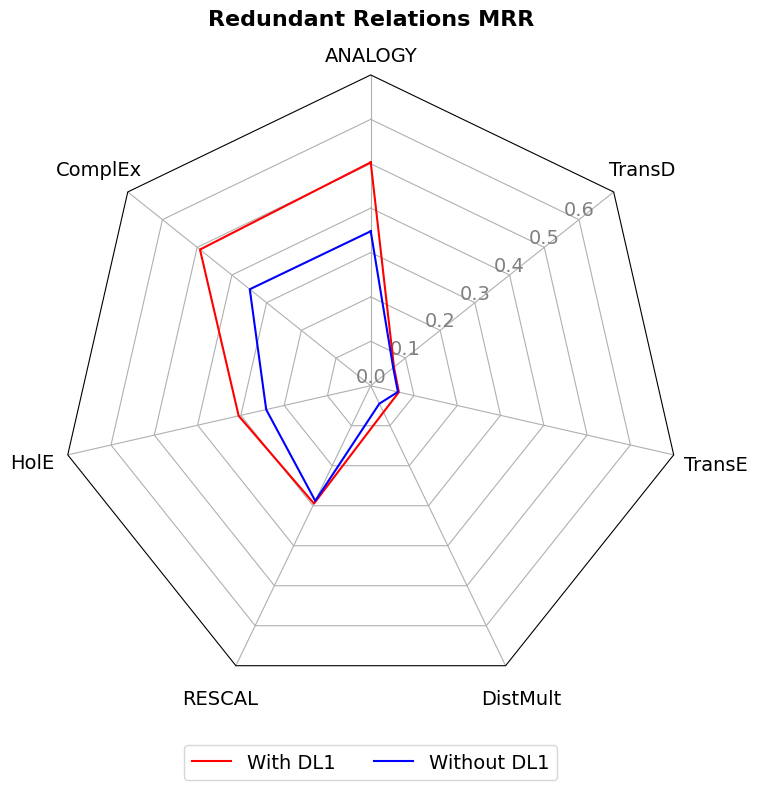

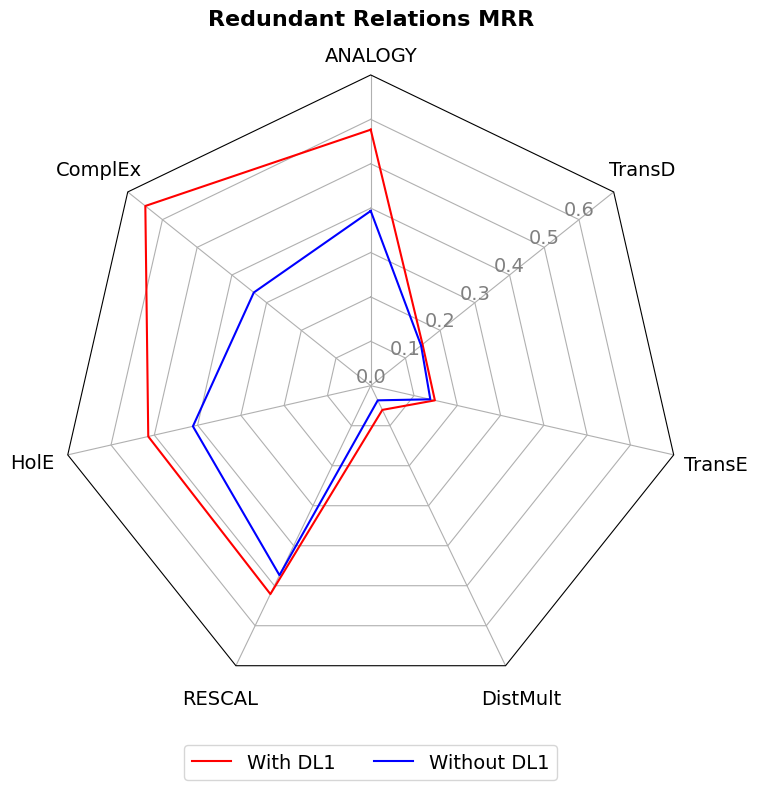

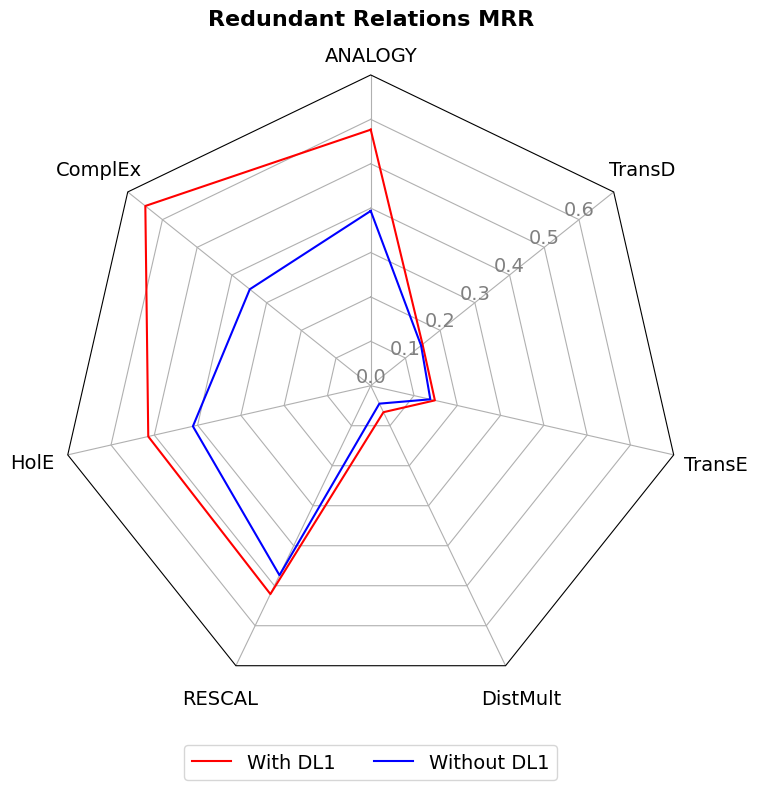

In [4]:
experiment1 = "with_dl1"  
experiment2 = "without_dl1" 
run = "run1" 
metric = "made_directed_relations" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"
title = "Redundant Relations MRR"
y_lim=0.7
labels = ["With DL1", "Without DL1"]
colors = ("red", "blue")
font_size=14

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "run2" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "best" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


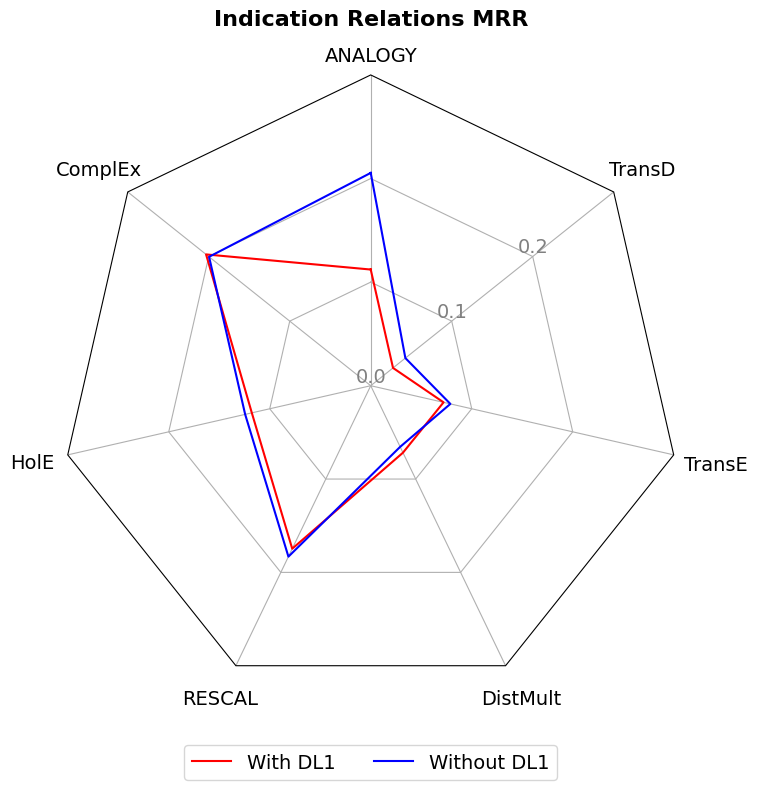

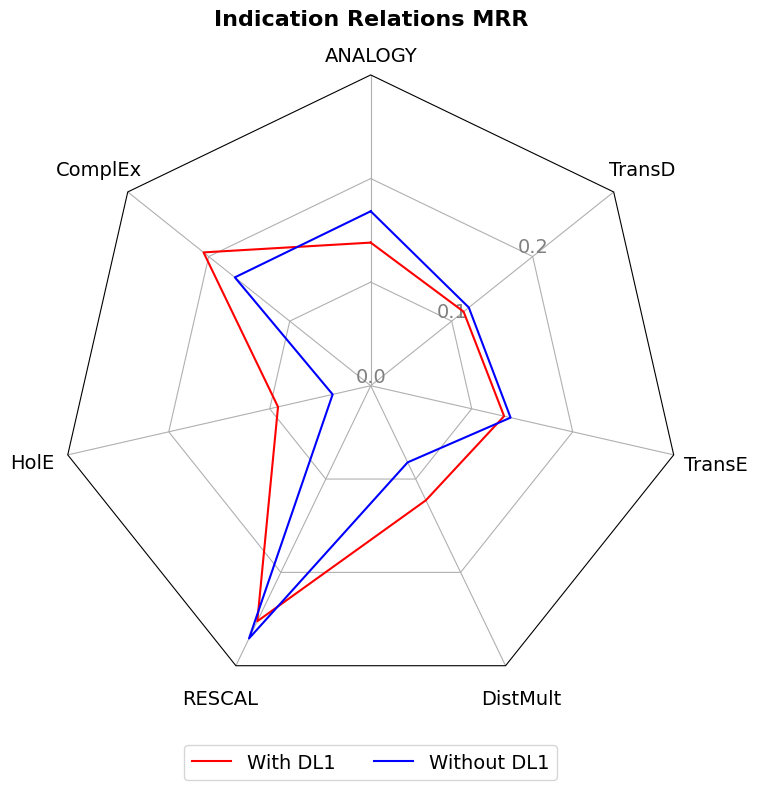

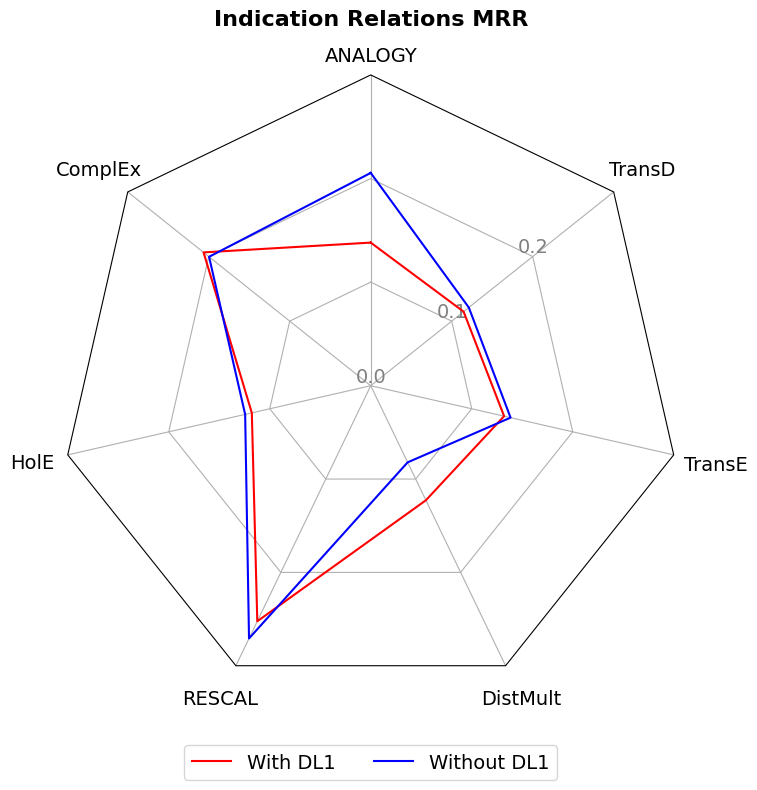

In [5]:
experiment1 = "with_dl1"  
experiment2 = "without_dl1" 
run = "run1" 
metric = "target_relations" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"
title = "Indication Relations MRR"
y_lim=0.3
labels = ["With DL1", "Without DL1"]
colors = ("red", "blue")
font_size=14

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "run2" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "best" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


# Figure 2

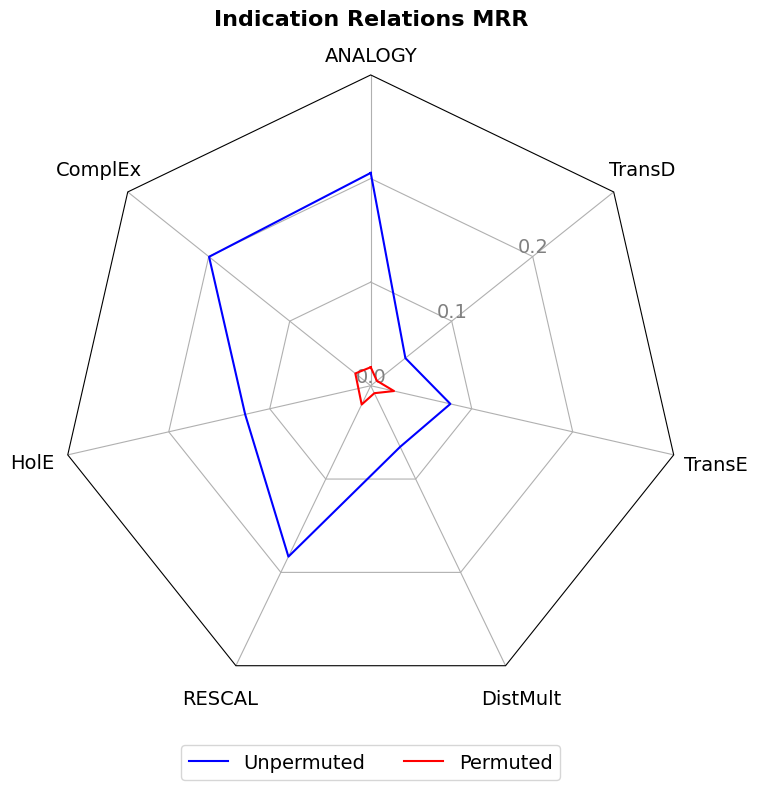

In [6]:
experiment1 = "without_dl1"  
experiment2 = "dl2" 
run = "run1" 
metric = "target_relations" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"
title = "Indication Relations MRR"
y_lim=0.3
labels = ["Unpermuted", "Permuted"]
colors = ("blue", "red")
font_size=14

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


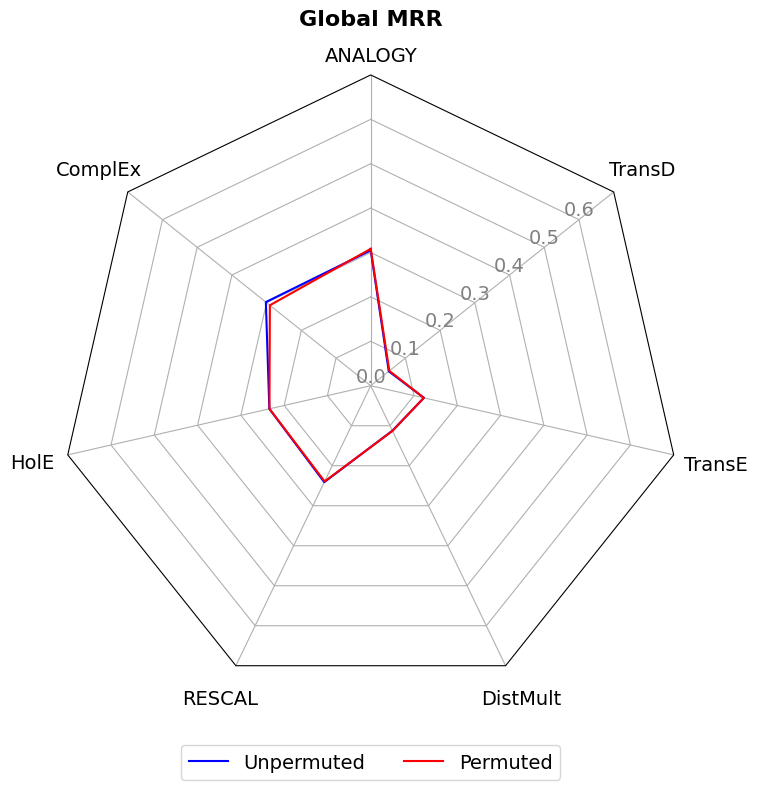

In [7]:
experiment1 = "without_dl1"  
experiment2 = "dl2" 
run = "run1" 
metric = "global_mrr" 
savefile = f"../figures/{experiment1}_{experiment2}_{run}_{metric}.svg"
title = "Global MRR"
y_lim=0.7
labels = ["Unpermuted", "Permuted"]
colors = ("blue", "red")
font_size=14

plot_radar(
    results=results, 
    metric1=metric, 
    experiment1=experiment1, 
    experiment2=experiment2, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


# Figure 3

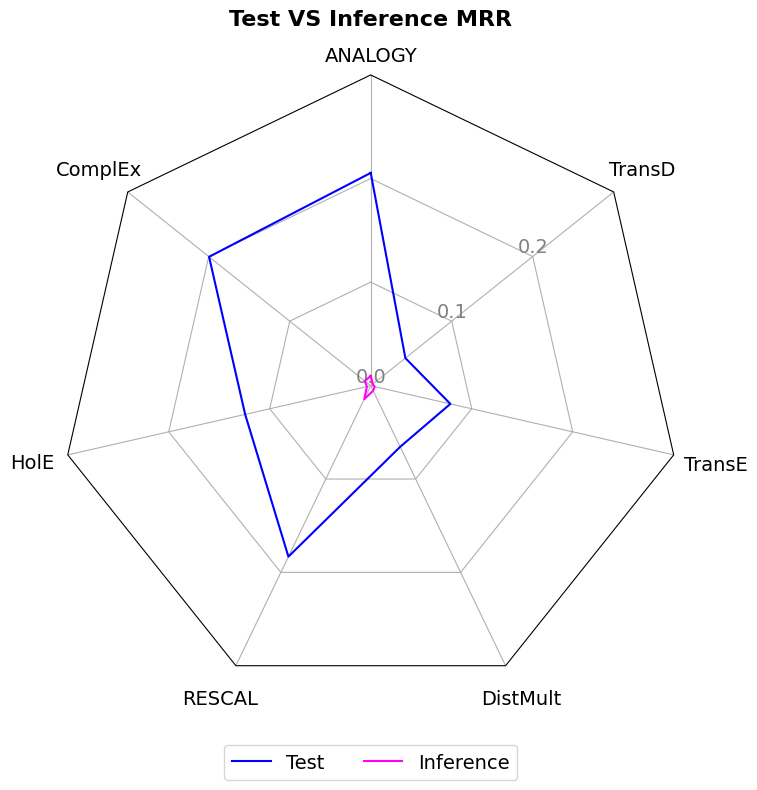

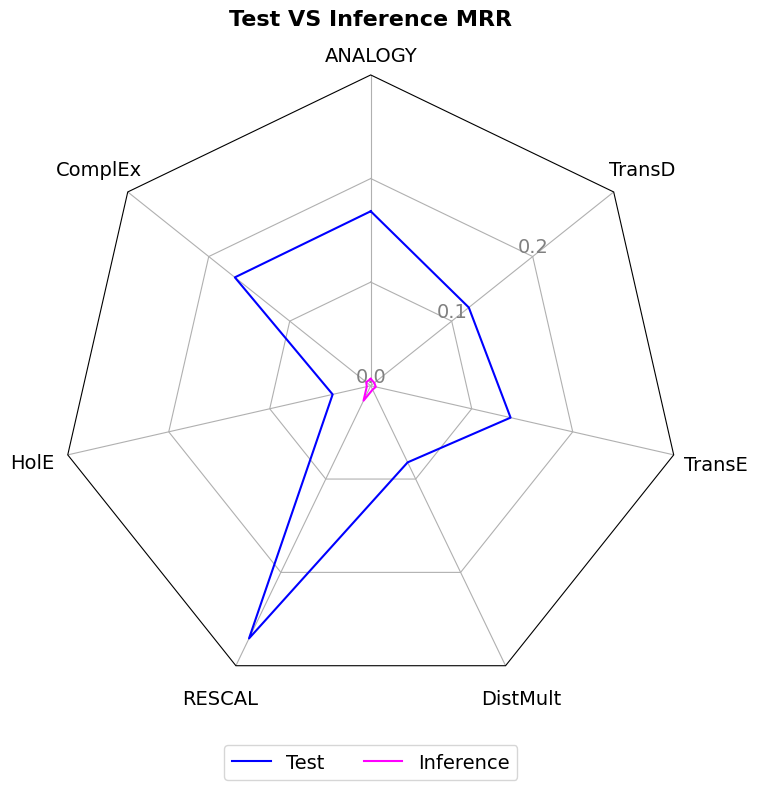

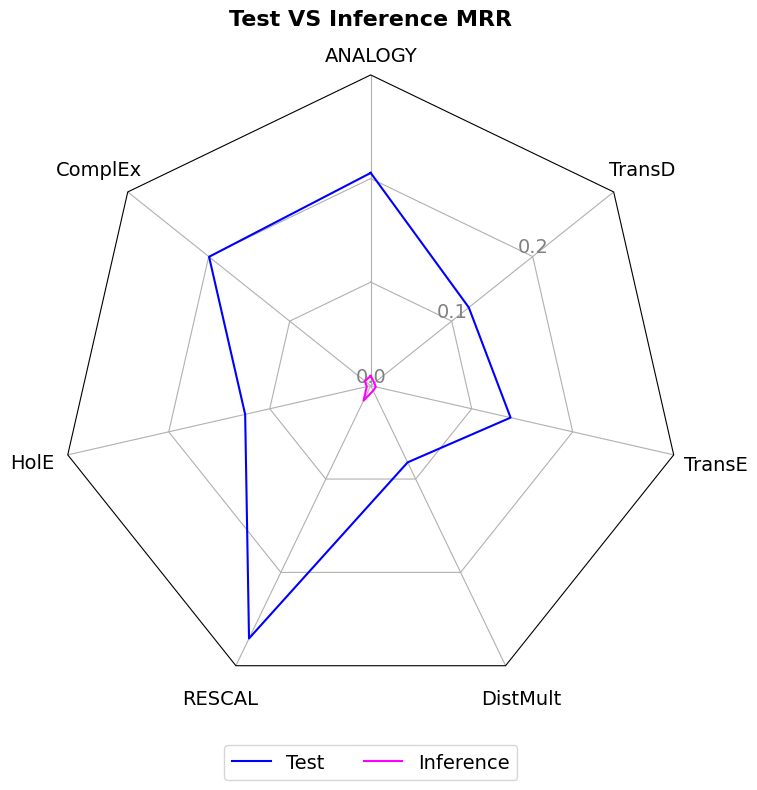

In [8]:
experiment1 = "without_dl1"  
run = "run1" 
metric2 = "inference_mrr" 
metric1 = "target_relations"
savefile = f"../figures/{experiment1}_{metric1}_{metric2}_{run}_{metric}.svg"
title = "Test VS Inference MRR"
y_lim=0.3
labels = ["Test", "Inference"]
colors = ("blue", "fuchsia")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    metric2=metric2,
    experiment1=experiment1, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "run2" 
savefile = f"../figures/{experiment1}_{metric1}_{metric2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric1, 
    metric2=metric2,
    experiment1=experiment1, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

run = "best" 
savefile = f"../figures/{experiment1}_{metric1}_{metric2}_{run}_{metric}.svg"

plot_radar(
    results=results, 
    metric1=metric1, 
    metric2=metric2,
    experiment1=experiment1, 
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


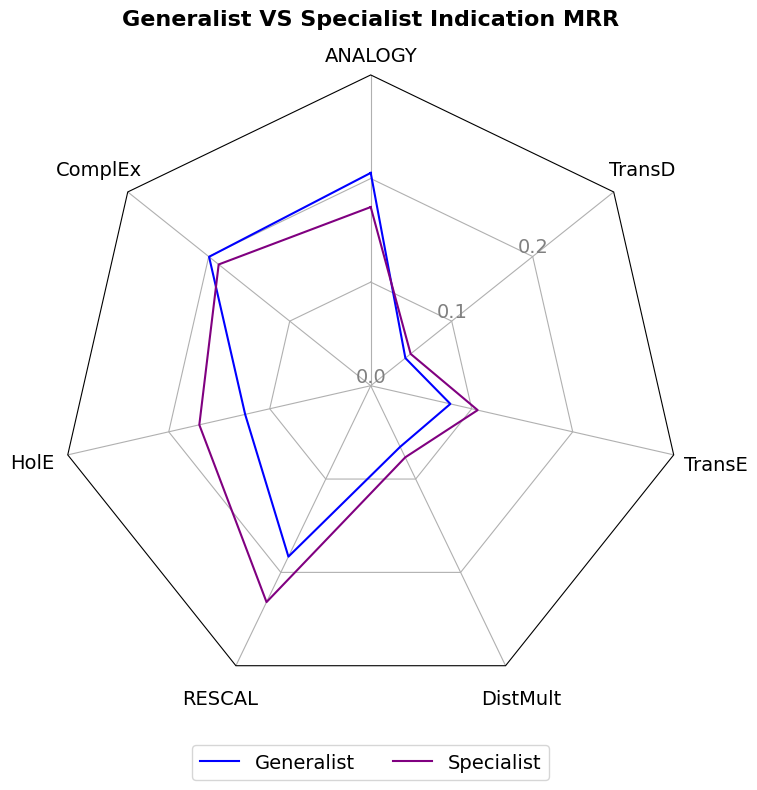

In [9]:
experiment1 = "without_dl1"  
experiment2 = "without_dl1_indication"
run = "run1" 
metric1 = "target_relations"
savefile = f"../figures/{experiment1}_{experiment2}_{metric1}_{run}_{metric}.svg"
title = "Generalist VS Specialist Indication MRR"
y_lim=0.3
labels = ["Generalist", "Specialist"]
colors = ("blue", "purple")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)

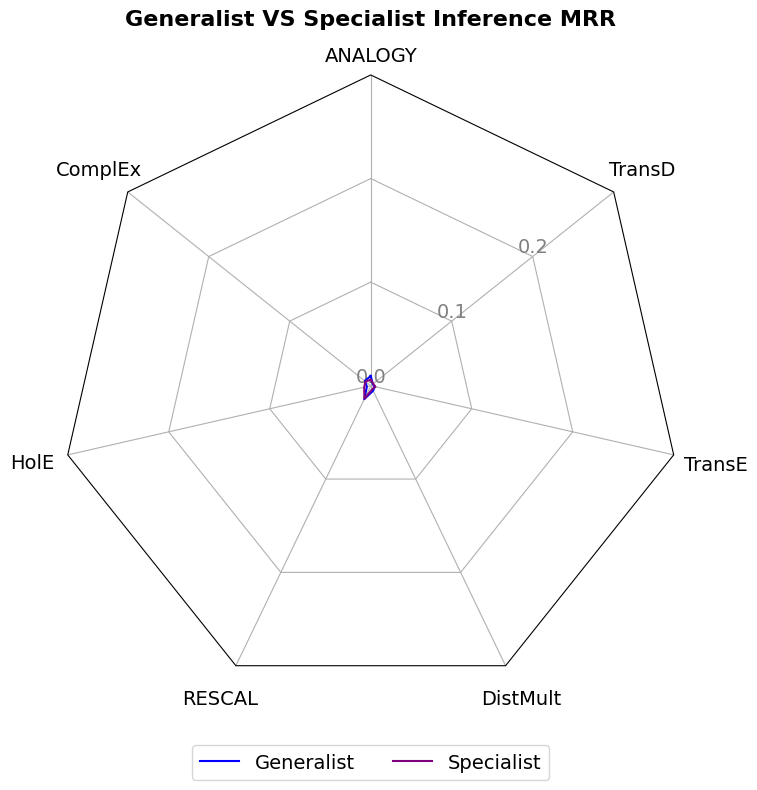

In [10]:
experiment1 = "without_dl1"  
experiment2 = "without_dl1_indication"
run = "run1" 
metric1 = "inference_mrr"
savefile = f"../figures/{experiment1}_{experiment2}_{metric1}_{run}_{metric}.svg"
title = "Generalist VS Specialist Inference MRR"
y_lim=0.3
labels = ["Generalist", "Specialist"]
colors = ("blue", "purple")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


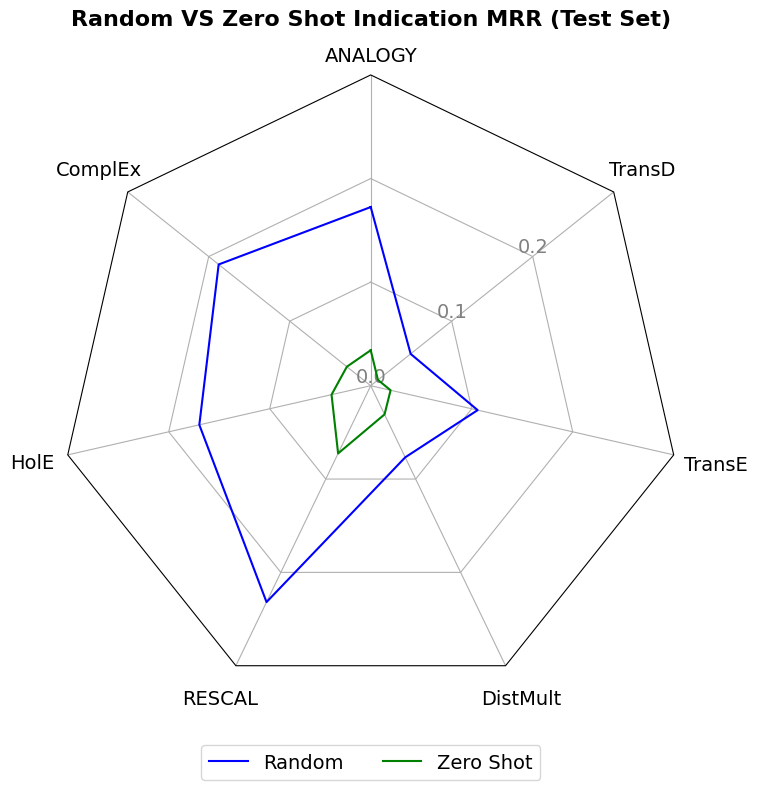

In [11]:
experiment1 = "without_dl1_indication"  
experiment2 = "zero_shot"
run = "run1" 
metric1 = "target_relations"
savefile = f"../figures/{experiment1}_{experiment2}_{metric1}_{run}.svg"
title = "Random VS Zero Shot Indication MRR (Test Set)"
y_lim=0.3
labels = ["Random", "Zero Shot"]
colors = ("blue", "green")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)


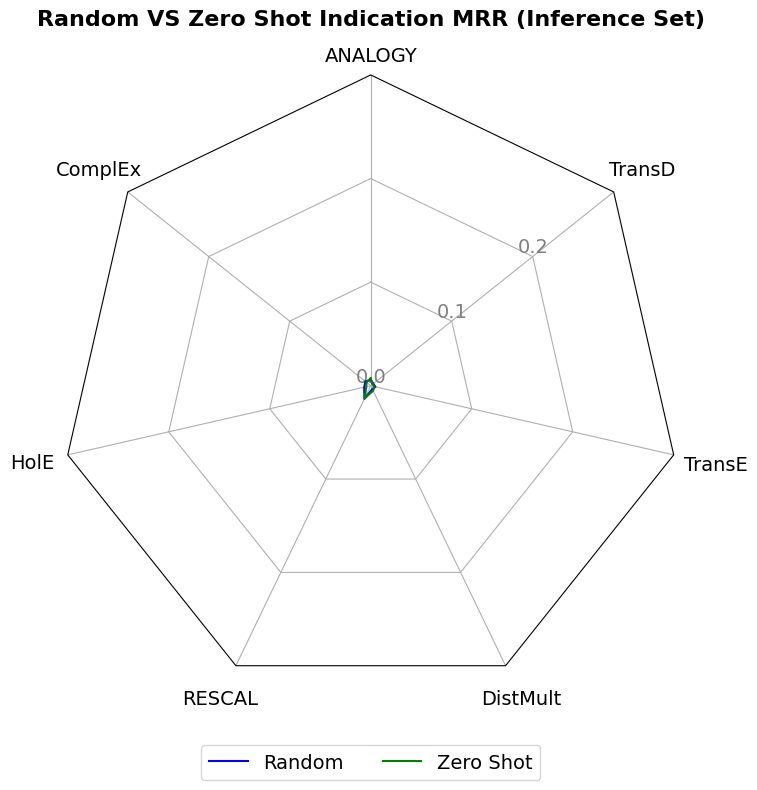

In [12]:
experiment1 = "without_dl1_indication"  
experiment2 = "zero_shot"
run = "run1" 
metric1 = "inference_mrr"
savefile = f"../figures/{experiment1}_{experiment2}_{metric1}_{run}.svg"
title = "Random VS Zero Shot Indication MRR (Inference Set)"
y_lim=0.3
labels = ["Random", "Zero Shot"]
colors = ("blue", "green")
font_size=14

plot_radar(
    results=results, 
    metric1=metric1, 
    experiment1=experiment1, 
    experiment2=experiment2,
    run=run, 
    y_lim=y_lim, 
    title=title, 
    legend_labels=labels, 
    colors=colors, 
    font_size=font_size,
    savefile=savefile
)
